In [1]:
!pip install grad-cam -q

Using device: cuda
--- SUCCESS: All Paths Found ---
Train Images: 9035 | Train Masks: 9035
Val Images:   1835 | Val Masks:   1835
Class weights applied to loss: [np.float64(3.504654771140419), np.float64(1.3992566207216974)]
Epoch 1/20: Loss=0.4592, Acc=0.7559, F1=0.8135
✔ Best model saved!
Epoch 2/20: Loss=0.3863, Acc=0.5586, F1=0.5846
Epoch 3/20: Loss=0.3598, Acc=0.7902, F1=0.8486
✔ Best model saved!
Epoch 4/20: Loss=0.3779, Acc=0.7411, F1=0.7993
Epoch 5/20: Loss=0.3540, Acc=0.7270, F1=0.7853
Epoch 6/20: Loss=0.3690, Acc=0.6131, F1=0.6553
Epoch 7/20: Loss=0.3636, Acc=0.7395, F1=0.7961
Epoch 8/20: Loss=0.2773, Acc=0.7602, F1=0.8173
Epoch 9/20: Loss=0.2711, Acc=0.7471, F1=0.8036
Epoch 10/20: Loss=0.2642, Acc=0.7646, F1=0.8218
Epoch 11/20: Loss=0.2619, Acc=0.7728, F1=0.8285
Epoch 12/20: Loss=0.2490, Acc=0.7760, F1=0.8319
Epoch 13/20: Loss=0.2378, Acc=0.7804, F1=0.8360
Epoch 14/20: Loss=0.2501, Acc=0.7684, F1=0.8245
Epoch 15/20: Loss=0.2424, Acc=0.7826, F1=0.8381
Epoch 16/20: Loss=0.2411

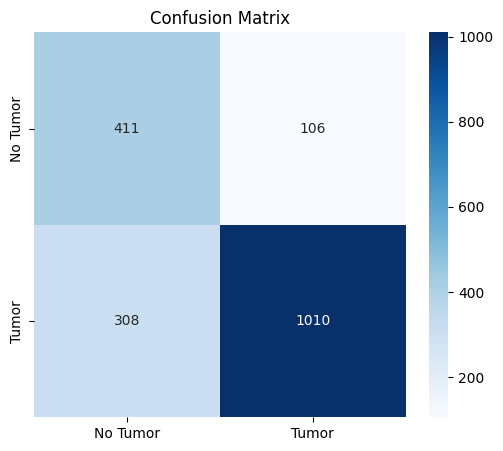

              precision    recall  f1-score   support

    No Tumor       0.57      0.79      0.67       517
       Tumor       0.91      0.77      0.83      1318

    accuracy                           0.77      1835
   macro avg       0.74      0.78      0.75      1835
weighted avg       0.81      0.77      0.78      1835

ROC-AUC: 0.8286


In [7]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ------------------- Install Grad-CAM -------------------
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ------------------- Config -------------------
DATA_PATH = '/kaggle/input/pancreas-cancer-segmentetion'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ------------------- Dataset -------------------
class PancreasDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            raise ValueError(f"Error loading file: {self.image_paths[idx]}")

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=0)

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        label = 1 if np.any(mask > 0) else 0

        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

# ------------------- FIXED DATA LOADING -------------------
def find_dir(name, start_path='/kaggle/input'):
    for root, dirs, files in os.walk(start_path):
        if name in dirs:
            return os.path.join(root, name)
    return None

train_img_dir = find_dir('X_train')
val_img_dir = find_dir('X_test')
train_mask_dir = find_dir('Y_train_Cancer')
val_mask_dir = find_dir('Y_test_Cancer')

if all([train_img_dir, val_img_dir, train_mask_dir, val_mask_dir]):
    train_img = sorted([os.path.join(train_img_dir, f) for f in os.listdir(train_img_dir)])
    train_mask = sorted([os.path.join(train_mask_dir, f) for f in os.listdir(train_mask_dir)])
    val_img = sorted([os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)])
    val_mask = sorted([os.path.join(val_mask_dir, f) for f in os.listdir(val_mask_dir)])
    
    print(f"--- SUCCESS: All Paths Found ---")
    print(f"Train Images: {len(train_img)} | Train Masks: {len(train_mask)}")
    print(f"Val Images:   {len(val_img)} | Val Masks:   {len(val_mask)}")
else:
    raise FileNotFoundError("Could not find one or more dataset directories.")

# ------------------- Transforms -------------------
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = PancreasDataset(train_img, train_mask, train_transform)
val_dataset = PancreasDataset(val_img, val_mask, val_transform)

# ------------------- Weighted Sampler -------------------
train_labels = [1 if np.any(cv2.imread(m, 0) > 0) else 0 for m in train_mask]
class_counts = np.bincount(train_labels)

# FIXED: Weight minority class higher
class_weights = [sum(class_counts)/c for c in class_counts]
print(f"Class weights applied to loss: {class_weights}")

weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ------------------- Hybrid Model -------------------
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        
        self.patch_embed = nn.Conv2d(2048, 768, kernel_size=1)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 768))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=12, dim_feedforward=3072,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)
        
        self.fc = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.transformer(x)
        x = x[:, 0]
        return self.fc(x)

model = HybridModel().to(DEVICE)

# ------------------- Training Setup -------------------
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)) # FIXED
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

# ------------------- Training Loop -------------------
best_f1 = 0
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            pred = outputs.argmax(dim=1).cpu().numpy()
            preds.extend(pred)
            gts.extend(labels.numpy())
    
    acc = accuracy_score(gts, preds)
    f1 = f1_score(gts, preds, zero_division=0)
    scheduler.step(f1)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={total_loss/len(train_loader):.4f}, Acc={acc:.4f}, F1={f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("✔ Best model saved!")

print(f"\nTraining completed! Best F1: {best_f1:.4f}")

# ==================== FINAL EVALUATION ====================
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor']))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC: {roc_auc:.4f}")

In [4]:
import os
import cv2

# ------------------- Auto-discover dataset directories -------------------
def find_dir(name, start_path='/kaggle/input'):
    for root, dirs, files in os.walk(start_path):
        if name in dirs:
            return os.path.join(root, name)
    return None

# Auto-find directories
train_img_dir = find_dir('X_train')
val_img_dir   = find_dir('X_test')
train_mask_dir = find_dir('Y_train_Cancer')
val_mask_dir   = find_dir('Y_test_Cancer')

# Check if all directories found
if not all([train_img_dir, val_img_dir, train_mask_dir, val_mask_dir]):
    raise FileNotFoundError("Could not find one or more dataset directories. Check names.")

# ------------------- Helper function to count classes -------------------
def count_classes(mask_dir):
    tumor, no_tumor = 0, 0
    for f in os.listdir(mask_dir):
        mask_path = os.path.join(mask_dir, f)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        if mask.sum() > 0:  # any pixel > 0 → Tumor
            tumor += 1
        else:
            no_tumor += 1
    return tumor, no_tumor

# ------------------- Count for Train and Validation -------------------
train_tumor, train_no_tumor = count_classes(train_mask_dir)
val_tumor, val_no_tumor     = count_classes(val_mask_dir)

print(f"Training Set: Tumor={train_tumor}, No Tumor={train_no_tumor}, Total={train_tumor + train_no_tumor}")
print(f"Validation Set: Tumor={val_tumor}, No Tumor={val_no_tumor}, Total={val_tumor + val_no_tumor}")

Training Set: Tumor=6457, No Tumor=2578, Total=9035
Validation Set: Tumor=1318, No Tumor=517, Total=1835


Using device: cuda
--- SUCCESS: All Paths Found ---
Train Images: 9035 | Train Masks: 9035
Val Images:   1835 | Val Masks:   1835
Epoch 1/25: Loss=0.4491, Acc=0.3128, F1=0.0842
✔ Best model saved!
Epoch 2/25: Loss=0.3712, Acc=0.6752, F1=0.7269
✔ Best model saved!
Epoch 3/25: Loss=0.3199, Acc=0.7619, F1=0.8195
✔ Best model saved!
Epoch 4/25: Loss=0.2903, Acc=0.7139, F1=0.7708
Epoch 5/25: Loss=0.2899, Acc=0.7749, F1=0.8311
✔ Best model saved!
Epoch 6/25: Loss=0.2547, Acc=0.7575, F1=0.8153
Epoch 7/25: Loss=0.2554, Acc=0.7673, F1=0.8252
Epoch 8/25: Loss=0.2442, Acc=0.7204, F1=0.7780
Epoch 9/25: Loss=0.2499, Acc=0.7678, F1=0.8254
Epoch 10/25: Loss=0.2119, Acc=0.7951, F1=0.8496
✔ Best model saved!
Epoch 11/25: Loss=0.1811, Acc=0.8027, F1=0.8543
✔ Best model saved!
Epoch 12/25: Loss=0.1716, Acc=0.8272, F1=0.8782
✔ Best model saved!
Epoch 13/25: Loss=0.1637, Acc=0.7935, F1=0.8482
Epoch 14/25: Loss=0.1647, Acc=0.8060, F1=0.8604
Epoch 15/25: Loss=0.1506, Acc=0.8060, F1=0.8613
Epoch 16/25: Loss=0

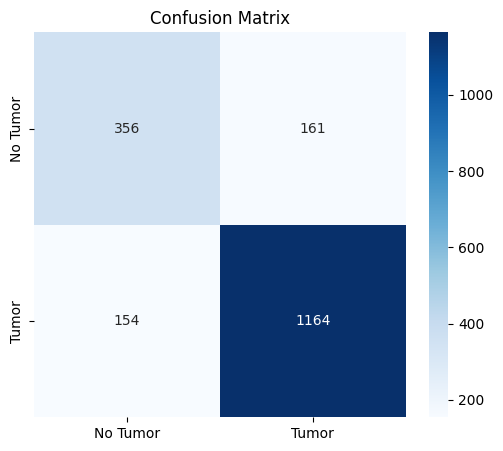

              precision    recall  f1-score   support

    No Tumor       0.70      0.69      0.69       517
       Tumor       0.88      0.88      0.88      1318

    accuracy                           0.83      1835
   macro avg       0.79      0.79      0.79      1835
weighted avg       0.83      0.83      0.83      1835

ROC-AUC: 0.8236


In [8]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ------------------- Install Grad-CAM -------------------
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ------------------- Config -------------------
DATA_PATH = '/kaggle/input/pancreas-cancer-segmentetion'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25        # Increased epochs for better convergence
LR = 5e-5          # Lower learning rate for stable training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ------------------- Dataset -------------------
class PancreasDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, clahe=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.clahe = clahe

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            raise ValueError(f"Error loading file: {self.image_paths[idx]}")

        # CLAHE for better contrast
        if self.clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img = clahe.apply(img)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
        img = np.stack([img, img, img], axis=0)

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        label = 1 if np.any(mask > 0) else 0

        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

# ------------------- Path Finder -------------------
def find_dir(name, start_path='/kaggle/input'):
    for root, dirs, files in os.walk(start_path):
        if name in dirs:
            return os.path.join(root, name)
    return None

train_img_dir = find_dir('X_train')
val_img_dir = find_dir('X_test')
train_mask_dir = find_dir('Y_train_Cancer')
val_mask_dir = find_dir('Y_test_Cancer')

if all([train_img_dir, val_img_dir, train_mask_dir, val_mask_dir]):
    train_img = sorted([os.path.join(train_img_dir, f) for f in os.listdir(train_img_dir)])
    train_mask = sorted([os.path.join(train_mask_dir, f) for f in os.listdir(train_mask_dir)])
    val_img = sorted([os.path.join(val_img_dir, f) for f in os.listdir(val_img_dir)])
    val_mask = sorted([os.path.join(val_mask_dir, f) for f in os.listdir(val_mask_dir)])
    print(f"--- SUCCESS: All Paths Found ---")
    print(f"Train Images: {len(train_img)} | Train Masks: {len(train_mask)}")
    print(f"Val Images:   {len(val_img)} | Val Masks:   {len(val_mask)}")
else:
    raise FileNotFoundError("Could not find one or more dataset directories.")

# ------------------- Transforms -------------------
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAdjustSharpness(2),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = PancreasDataset(train_img, train_mask, train_transform)
val_dataset = PancreasDataset(val_img, val_mask, val_transform)

# ------------------- Weighted Sampler -------------------
train_labels = [1 if np.any(cv2.imread(m, 0) > 0) else 0 for m in train_mask]
class_counts = np.bincount(train_labels)

# Use class weights to balance loss
class_weights = [sum(class_counts)/c for c in class_counts]
weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ------------------- Hybrid Model -------------------
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.patch_embed = nn.Conv2d(2048, 768, kernel_size=1)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 768))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=12, dim_feedforward=3072,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)
        self.fc = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.transformer(x)
        x = x[:, 0]
        return self.fc(x)

model = HybridModel().to(DEVICE)

# ------------------- Training Setup -------------------
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

# ------------------- Training Loop -------------------
best_f1 = 0
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            pred = outputs.argmax(dim=1).cpu().numpy()
            preds.extend(pred)
            gts.extend(labels.numpy())
    
    acc = accuracy_score(gts, preds)
    f1 = f1_score(gts, preds, zero_division=0)
    scheduler.step(f1)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: Loss={total_loss/len(train_loader):.4f}, Acc={acc:.4f}, F1={f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("✔ Best model saved!")

print(f"\nTraining completed! Best F1: {best_f1:.4f}")

# ------------------- Final Evaluation -------------------
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'])
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor']))

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC: {roc_auc:.4f}")